## Expected Credit Loss (ECL) Modeling for Retail Loans
## Notebook 4
## Preprocessing, LGD Modeling

---


## Author: Will Wu

## Date: 2025-11-14
---

## **Table of Contents** ##

1. [Setup and Loading](#1)
2. [Train Test Split](#2)
3. [Step 1: Classification Model](#3)
    - [Model Fitting and Evaluation](#3a)
    - [Apply regularization](#3b)
    - [Recovery Rate Instability](#3c)
4. [Step 2: Regression](#4)
    - [Beta Regression](#4a)
    - [Evaluate Model Performance](#4b)
    - [Deep Dive on Large Error Predictions](#4c)
5. [Summary](#5)


---

## Introduction
In this notebook, I will build a Loss Given Default (LGD) model to predict the percentage of loss on exposure when a borrower defaults on a loan. This model is typically used in conjunction with the Probability of Default (PD) model to calculate the expected loss associated with borrower defaults.

Mathematically, LGD is calculated using the formula:

$$\text{LGD} = 1 - \text{Recovery Rate (RR)}  = 1 - \frac{\text{Total Recoveries (Net of Costs)}}{\text{Exposure at Default (EAD)}}$$

During the exploratory data analysis (EDA), we observed that the LGD distribution exhibits a bimodal pattern. This non-continuous and non-normally distributed characteristic poses challenges for traditional regression models such as Ordinary Least Squares (OLS).

To effectively build this model, I will adopt a two-step approach. Rather than directly modeling LGD, I will model the recovery rate, allowing LGD to be derived as $$\text{LGD} = 1 - \text{Recovery Rate (RR)} $$

The two-step approach consists of:
1. **Step 1**: Model the binary outcome indicating whether the recovery rate is 0 or greater than 0.
2. **Step 2**: For observations where the recovery rate is greater than 0, I will use beta regression to estimate the recovery rate.

The calculatons of recovery rate can be expressed as: 
$$E[\text{Recovery Rate}] = \text{P}(\text{RR} = 1) \cdot 1 + \text{P}(\text{RR} = 0) \cdot 0 + \text{P}(0 < \text{RR} < 1) \cdot E[\text{RR} | 0 < \text{RR} < 1]$$

This method is expected to provide a more accurate and robust prediction of LGD.

---

## 1. Setup and Loading<a class="anchor" id="1"></a>

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error 
import joblib
import sys
import os

In [890]:
# Get the current directory of the notebook
current_directory = os.getcwd()
src_directory = os.path.join(current_directory, '../src')
sys.path.append(src_directory)

# Import the self_created class for model evaluation and downsampling
from model_evaluator import ModelEvaluator
from resampler import DownSampler

In [891]:
# Set Pandas option to display floats with 4 decimal places, preventing scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set the style
sns.set(style="whitegrid")

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [892]:
# Load the dataset
lgd_df = pd.read_csv("../data/loan_preprocessed.csv", index_col=0)

In [893]:
# Check the head
lgd_df.head(3)

,funded_amnt,int_rate,grade,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,inq_last_6mths,revol_util,total_acc,initial_list_status,is_default,exposure_at_default,loss_given_default,mths_since_delinq_category,issue_year,issue_month,state_group,is_revl_acct,is_term_60_mths,derogatory_pub_rec
1,7500,13.7500,E,OWN,22000.0000,Not Verified,Fully Paid,debt_consolidation,14.2900,1.0000,0.0000,51.5000,8.0000,f,0,0.0000,0.0000,in 1Yr,2007,6,State Group 3,0,0,0 record
2,6000,10.5900,C,RENT,20000.0000,Not Verified,Does not meet the credit policy. Status:Fully ...,debt_consolidation,12.9000,0.0000,4.0000,66.0000,6.0000,f,0,0.0000,0.0000,More than 2Yrs,2007,6,State Group 3,0,0,0 record
3,4400,9.6400,B,MORTGAGE,30000.0000,Not Verified,Does not meet the credit policy. Status:Fully ...,debt_consolidation,3.7200,0.0000,0.0000,63.5000,5.0000,f,0,0.0000,0.0000,in 1Yr,2007,6,State Group 4,0,0,0 record


In [894]:
# Check the shape
lgd_df.shape

(232502, 24)

- Since LGD and RR only applies to default borrowers, we will filter our observations by using default loans only.

In [895]:
# Filter users that defeualt
lgd_df_filtered = lgd_df[lgd_df['is_default'] == 1].copy()

# Check shape
lgd_df_filtered.shape

(48128, 24)

- Create recovery rate target variable

In [896]:
# Create recovery rate
lgd_df_filtered['recovery_rate'] = 1 - lgd_df_filtered['loss_given_default']

In [897]:
# Round recovery rate to 2 decimal places
lgd_df_filtered['recovery_rate'] = round(lgd_df_filtered['recovery_rate'], 2) 

---

## 2. Train Test Split <a class="anchor" id="2"></a>

In [898]:
# Out-of-time split. 80% training, 20% testing.
train, test = np.split(lgd_df_filtered, [int(0.8 * len(lgd_df_filtered))])

# Check size
print(f"Training set size: {len(train)}, \
        LGD: {train['loss_given_default'].mean():.3f}")

print(f"Testing set size: {len(test)}, \
         LGD: {test['loss_given_default'].mean():.3f}")

Training set size: 38502,         LGD: 0.929
Testing set size: 9626,          LGD: 0.969


In [899]:
# Add label for visualization
train['set'] = 'train'
test['set'] = 'test'

In [900]:
# Create the issue_d column
train['issue_d'] = pd.to_datetime(train['issue_year'].astype(str) + '-' + train['issue_month'].astype(str) + '-01')
test['issue_d'] = pd.to_datetime(test['issue_year'].astype(str) + '-' + test['issue_month'].astype(str) + '-01')

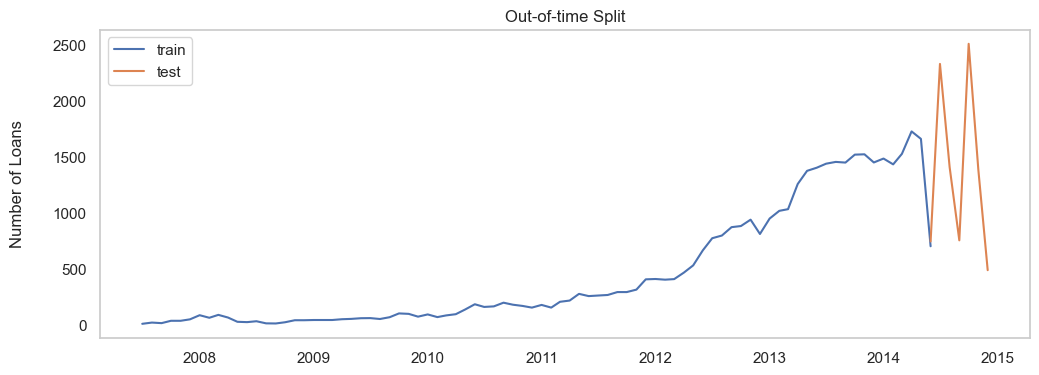

In [901]:
# Plot the out-of-time split.
train_test = pd.concat([train, test])
train_test = train_test.groupby(['issue_d', 'set'])['is_default'].count().reset_index().rename(columns={'is_default': 'loans'})

fig, ax = plt.subplots(figsize=(12, 4))
plt.title('Out-of-time Split')
sns.lineplot(train_test, x='issue_d', y='loans', hue='set', ax=ax)
plt.xlabel('')
plt.ylabel('Number of Loans', labelpad=20)
plt.grid(False)
plt.legend(loc='upper left')
plt.show()

# Drop columns used only for plotting.
to_drop = ['issue_d', 'set']
train = train.drop(columns=to_drop)
test = test.drop(columns=to_drop)

- Remove irrelavant columns


In [902]:
# Define the list of columns to exclude
cols_to_drop = ['is_default', 'exposure_at_default', 'loan_status', 'loss_given_default'] 

In [903]:
# Drop irrelavant columns
train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

- Add one more column for step 1 model: RR=0 or RR >0

In [904]:
# Add one more column for step 1 mode
train['rr_equals_to_zero'] =  np.where(train['recovery_rate'] == 0, 1, 0)
test['rr_equals_to_zero'] =  np.where(test['recovery_rate'] == 0, 1, 0)

Note the differenece in proportions might raise challenges in modeling.

- Classification model: logistic regression predicting: RR=0 or RR >0

In [905]:
# Create X and y for classification model
X_train_classification = train.drop(columns=['recovery_rate', 'rr_equals_to_zero'])
y_train_classification = train['rr_equals_to_zero'].copy()
X_test_classification = test.drop(columns=['recovery_rate', 'rr_equals_to_zero'])
y_test_classification = test['rr_equals_to_zero'].copy()

# Check shape
print("Model 1: Classification using Logistic Regression:")
print(f"X_train shape: {X_train_classification.shape}")
print(f"y_train shape: {y_train_classification.shape}")
print(f"X_test shape: {X_test_classification.shape}")
print(f"y_test shape: {y_test_classification.shape}")

Model 1: Classification using Logistic Regression:
X_train shape: (38502, 20)
y_train shape: (38502,)
X_test shape: (9626, 20)
y_test shape: (9626,)


- Regression model: Beta regression estimating the recovery rate given recovery rate >0

In [965]:
# Filter the training data to include only rows where rr_equals_to_zero is False (i.e., recovery_rate > 0)
train_filtered = train[(train['recovery_rate'] !=0) & (train['recovery_rate'] !=1)]

# Create X and y for regression model from the filtered training data
X_train_regression = train_filtered.drop(columns=['recovery_rate', 'rr_equals_to_zero'])
y_train_regression = train_filtered['recovery_rate'].copy()

# Filter the test data similarly
test_filtered = test[(test['recovery_rate'] !=0) & (test['recovery_rate'] !=1)]
X_test_regression = test_filtered.drop(columns=['recovery_rate', 'rr_equals_to_zero'])
y_test_regression = test_filtered['recovery_rate'].copy()

# Check shape
print("Model: Regression using Linear Regression:")
print(f"X_train shape: {X_train_regression.shape}")
print(f"y_train shape: {y_train_regression.shape}")
print(f"X_test shape: {X_test_regression.shape}")
print(f"y_test shape: {y_test_regression.shape}")

Model: Regression using Linear Regression:
X_train shape: (20011, 20)
y_train shape: (20011,)
X_test shape: (1947, 20)
y_test shape: (1947,)


---

## 3. Step 1: Classification Model <a class="anchor" id="3"></a>

### 3.1 Model Fitting and Evaluation <a class="anchor" id="3a"></a>

Since beta regression in Step 2 excludes values of 0 and 1, Step 1 of the Loss Given Default (LGD) or Recovery Rate (RR) prediction involves determining whether the recovery rate is equal to 0 or greater than 0.

In [ ]:
# Find categorical columns in X_train
categorical_columns = X_train_classification.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = X_train_classification.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
ordinal_columns = ['grade']  

# Remove 'grade' and 'sub_grade' from categorical columns
categorical_columns = [col for col in categorical_columns if col not in ['grade']]

# Sanity check
print(f"Number of cols in total: {len(categorical_columns) + len(numerical_columns) + len(ordinal_columns)}")

Number of cols in total: 20


In [ ]:
# Define the preprocessing pipeline for ordinal columns
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder()),
    ('scaler', StandardScaler())
])

# Create a column transformer
preprocessor = ColumnTransformer(  
    transformers=[
        ('cat_cols', OneHotEncoder(sparse_output=False,
                                   handle_unknown='ignore',
                                   drop='first'), categorical_columns),  
        ('num_cols', StandardScaler(), numerical_columns),
        ('ord_cols', ordinal_pipeline, ordinal_columns)       
    ]
)

In [989]:
# Create the pipeline using logistic regression
pipeline_logreg = Pipeline([
    ('one_hot_encoding', preprocessor),
    ('logreg', LogisticRegression())
])


In [990]:
# Fit the model
pipeline_logreg.fit(X_train_classification, y_train_classification)

Pipeline(steps=[('one_hot_encoding',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose',
                                                   'initial_list_status',
                                                   'mths_since_delinq_category',
                                                   'state_group',
                                                   'derogatory_pub_rec']),
                                                 ('num_cols', StandardScaler(),
                                                  ['funded_amnt', 'int_rate',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'revol_util', 'total_acc',
                                                   'issue_year', 'issue_month',
                                                   'is_revl_acct',
                                                   'is_term_60_mths']),
                                                 ('ord_cols',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['grade'])])),
                ('logreg', LogisticRegression())])

Evaluation: Logistic Regression
Confusion matrices: 


<Figure size 300x300 with 0 Axes>

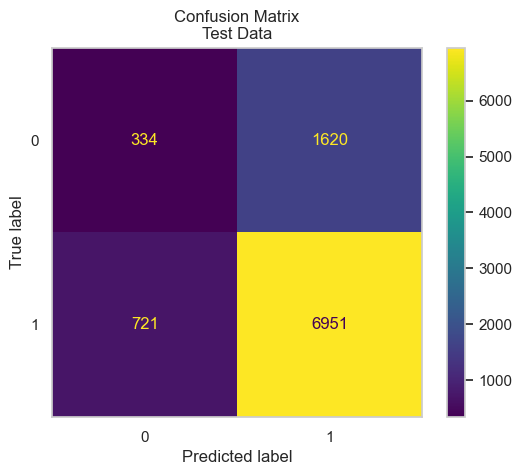

Test Data Classification Report: 
==================================================================               precision    recall  f1-score   support

           0       0.32      0.17      0.22      1954
           1       0.81      0.91      0.86      7672

    accuracy                           0.76      9626
   macro avg       0.56      0.54      0.54      9626
weighted avg       0.71      0.76      0.73      9626

Recall Score:
Train: 0.543
Test: 0.906 
False Positive Rate:
Train: 0.312
Test: 0.829 
AUC Score:
Train: 0.658
Test: 0.614 
Accuracy Score:
Train: 0.618
Test: 0.757 
Precision Score:
Train: 0.615
Test: 0.811 
F1 Score:
Train: 0.577
Test: 0.856 


In [991]:
# Use self-built ModelEvaluator to evaluate the mode
print("Evaluation: Logistic Regression")
evaluator = ModelEvaluator(pipeline_logreg)
evaluator.evaluate(X_train_classification, X_test_classification, y_train_classification, y_test_classification)

ROC Curve: Logistic Regression


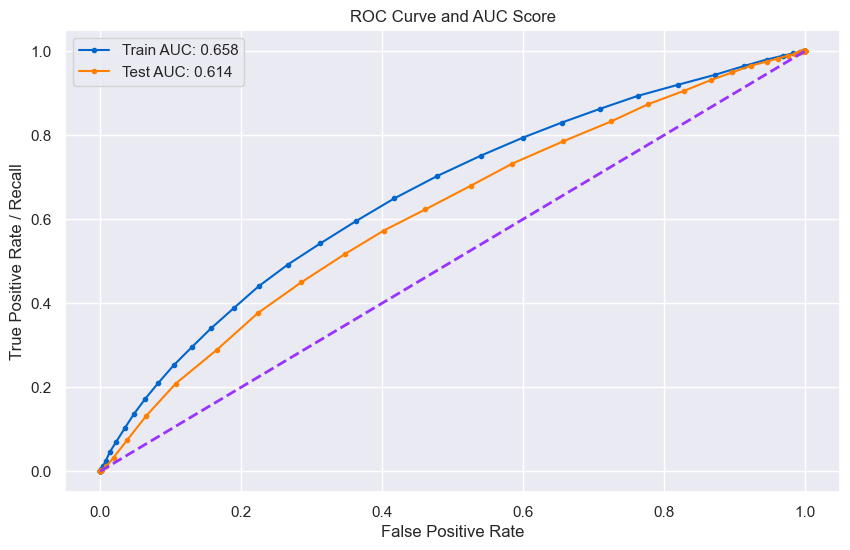

In [853]:
# Plot the roc curve 
print('======='*8)
print('ROC Curve: Logistic Regression')
print('======='*8)
evaluator.plot_roc_auc_curve(X_train_classification, X_test_classification, y_train_classification, y_test_classification)

- **Insights:**

From the observation of model metrics, some of the issues can be observed:
1. Overfitting:. as the model's train AUC score notably outperformed test AUC score, the model's rank ordering learnt during training did not generalize well out of time.
2. Decision threshold mismatch: the large, contradictory shifts in the classification metrics (recall, false positive rate, precision) strongly suggests that the cedesion threshold used to convert the model's continuous probabillity into the final binary classifications is not consistent or appropriate between train and test sets.
    - high test recall and test FPR: the model is being overly aggresive and classifying many loans to the positive class (predict RR = 0). The high FPR indicates that over 60 of teh actual negative class were incorrectly flagged as psitive, indicating the threshold is too low in the test set
    - high test precision: this contradicts the high FPR. This unsuanal combinantion on high FPR and high precision suggests a fundamental difference in the classs distribution, leading to the inconsistentcies between train and test metrics.
3. Possible distribution shift: given that we use an out-of-time split and we saw the shift in PD distribution over time, the mose likely root cause for these dramatic shifts is **Data Drift**.

---

### 3.2 Apply regularization <a class="anchor" id="3b"></a>

Here I will try to use the regularization for fixing the overfitting. In order to make the result more robust and stable results.

- L2 (Ridge) Regularizaiton: 
the penalty: $\sum \beta_i^2$


In [854]:
# Define the range of C values to test 
C_values = [0.00001, 0.001, 0.01, 0.1, 1, 10] # [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

In [855]:
# Prepare lists to store results
train_scores_l2 = []
validation_scores_l2 = []

In [856]:
# Define the Time Series Cross-Validator
tscv = TimeSeriesSplit(n_splits=5) 

print("Starting C Hyperparameter Tuning using Time Series Cross-Validation...")

# Loop over different C values
for C in C_values:
    # Define the pipeline for the current C value
    pipeline_logreg = Pipeline([
        ('one_hot_encoding', preprocessor),
        ('logreg', LogisticRegression(
            penalty='l2',        
            solver='liblinear',  
            C=C,                 # Dynamic C value from the loop
            random_state=42
        ))
    ])
    
    # Perform Cross-Validation and collect both train and test scores
    scores = cross_validate(
        estimator=pipeline_logreg,
        X=X_train_classification, 
        y=y_train_classification, 
        cv=tscv,  # Use the TimeSeriesSplit
        scoring='roc_auc', 
        return_train_score=True, # Must be True to analyze overfitting gap
        n_jobs=-1
    )
    
    # Store the mean scores for plotting
    train_scores_l2.append(np.mean(scores['train_score']))
    validation_scores_l2.append(np.mean(scores['test_score'])) # test_score is the validation score

    print(f"C={C:.4f} | Train AUC: {train_scores_l2[-1]:.4f} | Val AUC: {validation_scores_l2[-1]:.4f}")

Starting C Hyperparameter Tuning using Time Series Cross-Validation...
C=0.0000 | Train AUC: 0.6038 | Val AUC: 0.5385
C=0.0010 | Train AUC: 0.6278 | Val AUC: 0.5658
C=0.0100 | Train AUC: 0.6371 | Val AUC: 0.5773
C=0.1000 | Train AUC: 0.6390 | Val AUC: 0.5795
C=1.0000 | Train AUC: 0.6392 | Val AUC: 0.5796
C=10.0000 | Train AUC: 0.6393 | Val AUC: 0.5796


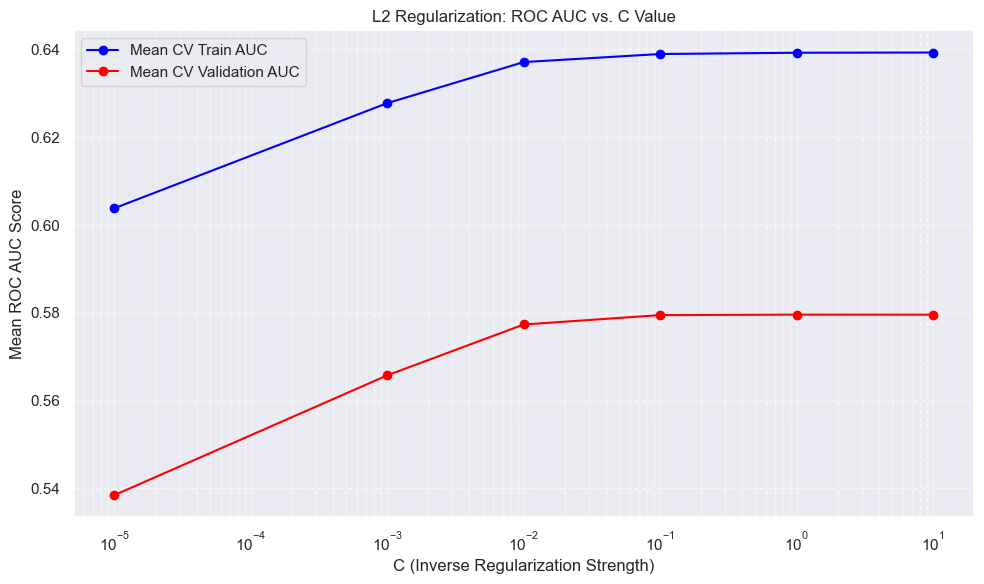

In [857]:
# Plot the train and validation scores
plt.figure(figsize=(10, 6))

# Plot the scores
plt.plot(C_values, train_scores_l2, label='Mean CV Train AUC', marker='o', color='blue')
plt.plot(C_values, validation_scores_l2, label='Mean CV Validation AUC', marker='o', color='red')


# Add labels and title
plt.xscale('log') 
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Mean ROC AUC Score')
plt.title('L2 Regularization: ROC AUC vs. C Value')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


- L1 (Lasso) Regularizaiton: 
the penalty: $\sum \mid\beta_i\mid$


In [858]:
# Prepare lists to store results
train_scores_l1 = []
validation_scores_l1 = []

In [859]:
# Define the Time Series Cross-Validator
tscv = TimeSeriesSplit(n_splits=5) 

print("Starting C Hyperparameter Tuning for L1 Regularization...")

# Loop over different C values
for C in C_values:
    # Define the pipeline for the current C value
    pipeline_logreg = Pipeline([
        ('one_hot_encoding', preprocessor),
        ('logreg', LogisticRegression(
            penalty='l1',        # Changed to L1 regularization 
            solver='liblinear',  
            C=C,                 
            random_state=42
        ))
    ])
    
    # Perform Cross-Validation and collect both train and test scores
    scores = cross_validate(
        estimator=pipeline_logreg,
        X=X_train_classification, 
        y=y_train_classification, 
        cv=tscv,  # Use the TimeSeriesSplit
        scoring='roc_auc', 
        return_train_score=True, # Must be True to analyze overfitting gap
        n_jobs=-1
    )
    
    # Store the mean scores for plotting
    train_scores_l1.append(np.mean(scores['train_score']))
    validation_scores_l1.append(np.mean(scores['test_score'])) # test_score is the validation score

    print(f"C={C:.4f} | Train AUC: {train_scores_l1[-1]:.4f} | Val AUC: {validation_scores_l1[-1]:.4f}")

Starting C Hyperparameter Tuning for L1 Regularization...
C=0.0000 | Train AUC: 0.5000 | Val AUC: 0.5000
C=0.0010 | Train AUC: 0.5359 | Val AUC: 0.5029
C=0.0100 | Train AUC: 0.6247 | Val AUC: 0.5689
C=0.1000 | Train AUC: 0.6375 | Val AUC: 0.5785
C=1.0000 | Train AUC: 0.6391 | Val AUC: 0.5795
C=10.0000 | Train AUC: 0.6393 | Val AUC: 0.5796


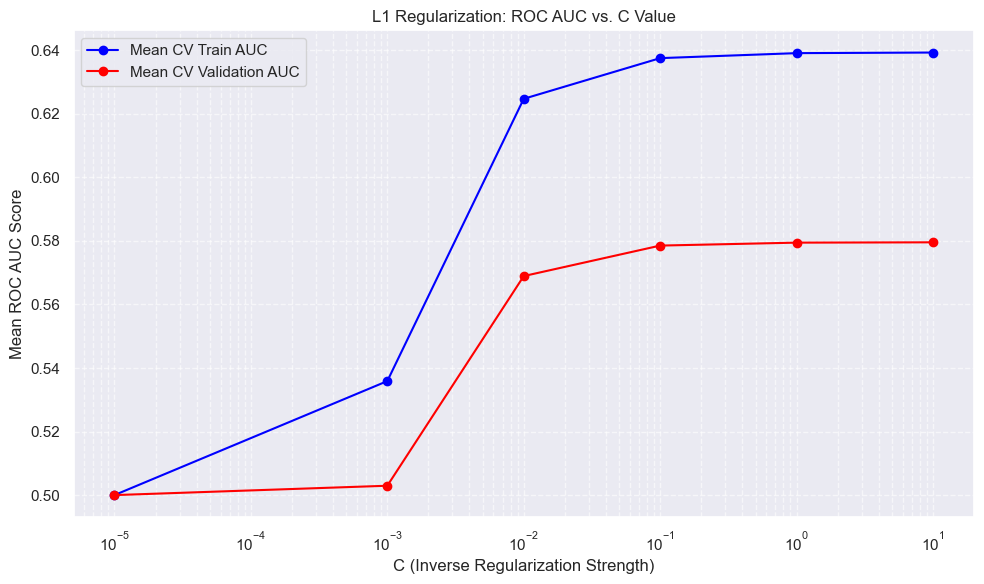

In [860]:
# Plot the train and validation scores
plt.figure(figsize=(10, 6))

# Plot the scores
plt.plot(C_values, train_scores_l1, label='Mean CV Train AUC', marker='o', color='blue')
plt.plot(C_values, validation_scores_l1, label='Mean CV Validation AUC', marker='o', color='red')


# Add labels and title
plt.xscale('log') 
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Mean ROC AUC Score')
plt.title('L1 Regularization: ROC AUC vs. C Value')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

- **Insights:**

1. I experimented with both L2 and L1 regularization across a range of regularization strengths for the logistic regression model. However, it consistently exhibited signs of overfitting with all combinations of hyperparameters. Additionally, when applying a strong regularization with $C = 10^{-5}$, the model displayed underfitting.

2. The results strongly suggest that there is a fundamental structural issue affecting the stability of the data.

---

### 3.3 Recovery Rate Instability <a class="anchor" id="3c"></a>

In [861]:
# Assuming your environment has the required variables:
train_proportion = y_train_classification.mean()
test_proportion = y_test_classification.mean()

print(f"Training Set (RR=0) Proportion: {train_proportion:.4f}")
print(f"Testing Set (RR=0) Proportion: {test_proportion:.4f}")

difference = test_proportion - train_proportion
print(f"Difference (Test - Train): {difference:.4f}")

Training Set (RR=0) Proportion: 0.4793
Testing Set (RR=0) Proportion: 0.7970
Difference (Test - Train): 0.3177


- Here the mean represents the probability of zero recovery rate (RR=0) within the dataset (Train/Test), and we can tell that there is a significant difference.

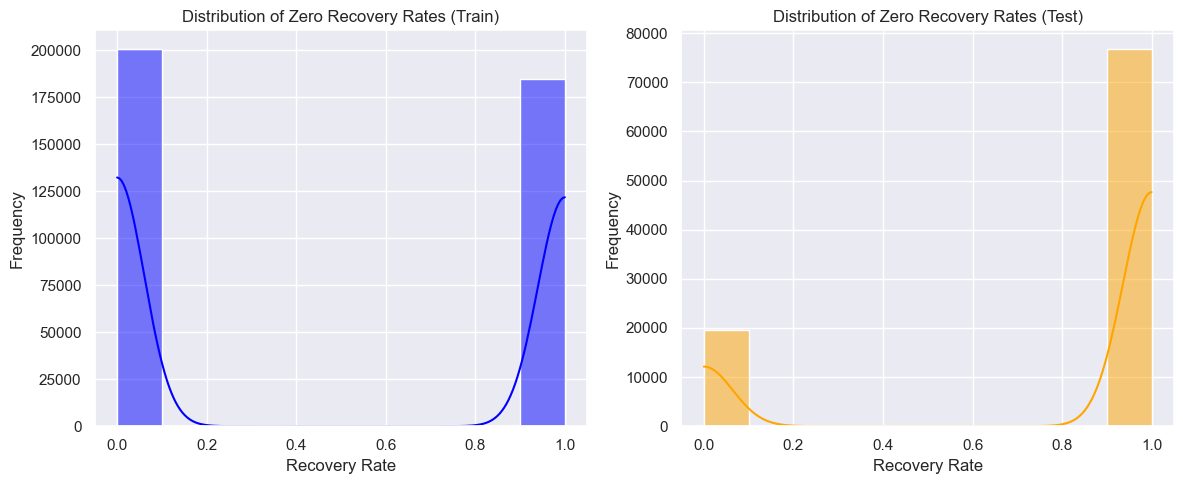

In [862]:
# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plotting the distribution for y_train
sns.histplot(y_train_classification, bins=10, ax=axes[0], stat='frequency', color='blue', kde=True)
axes[0].set_title('Distribution of Zero Recovery Rates (Train)')
axes[0].set_xlabel('Recovery Rate')
axes[0].set_ylabel('Frequency')

# Plotting the distribution for y_test
sns.histplot(y_test_classification, bins=10, ax=axes[1], stat='frequency', color='orange', kde=True)
axes[1].set_title('Distribution of Zero Recovery Rates (Test)')
axes[1].set_xlabel('Recovery Rate')
axes[1].set_ylabel('Frequency')

# Display the plots
plt.tight_layout()
plt.show()

The distribution graph again confirms that the change in recovery rate distribution sets was the root cause of model performance instability.

---

### Summary <a class="anchor" id="3d"></a>



1. The distribution of Recovery Rates (RR) reveals a significant structural shift between the training and testing datasets. In the training period, defaults mostly resulted in total losses (RR = 0), while the testing period exhibits a shift where full recoveries (RR = 1) dominate. This indicates a fundamental change in recovery mechanics, likely influenced by variations in collateral value, borrower income, or regulatory conditions. Consequently, the current Logistic Regression model, trained on a different economic environment, struggles with this new context, leading to substantial overfitting.

2. To enhance model performance, it is crucial to incorporate macroeconomic indicators, such as the GDP, Home Price Index, or unemployment rates, that can account for these shifts in recovery behavior, and potentially improve model's performance in predciting power with changing distribution.

3. Assuming recovery rate characteristics remain stable over time, the model—after hyperparameter tuning—achieves an AUC score of 0.66, signifying moderate discrimination between positive and negative outcomes, along with an accuracy of 0.64. While there is potential for predictive capability, further improvements are needed for better classification of recovery rates.


---


## 4. Step 2: Regression <a class="anchor" id="4"></a>

In this part, I will build regression to estimate the partial recovery, or recovery rate between 0 and 1. This will help us to complete the calcualtion of recovery rate calcualtions for all borrowers who have defaulted.

### 4.1 Beta Regression <a class="anchor" id="4a"></a>

In [966]:
# Fit and transform the training data
X_train_transformed = preprocessor.fit_transform(X_train_regression)

# Transform the test data
X_test_transformed = preprocessor.transform(X_test_regression)

In [967]:
# Create new columns names after OneHotEncoding
ohe_cols = preprocessor.named_transformers_['cat_cols'].get_feature_names_out(categorical_columns)
all_columns = list(ohe_cols) + numerical_columns + ordinal_columns

# Create datafrome for interpretation
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_columns)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_columns)

In [968]:
# Check the preprocessed data
X_train_transformed_df.head()

,home_ownership_OWN,home_ownership_Other_none_any,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,mths_since_delinq_category_More than 2Yrs,mths_since_delinq_category_in 1Yr,mths_since_delinq_category_in 2Yrs,state_group_State Group 2,state_group_State Group 3,state_group_State Group 4,state_group_State Group 5,state_group_State Group 6,derogatory_pub_rec_1 record,derogatory_pub_rec_2 records,derogatory_pub_rec_3+ records,funded_amnt,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,revol_util,total_acc,issue_year,issue_month,is_revl_acct,is_term_60_mths,grade
0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,-1.3931,-0.4067,-0.6606,-0.0384,5.0692,3.2799,-0.3251,0.4229,-4.1029,0.1606,-1.3657,-0.7369,1.1065
1,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.6513,-0.2592,0.3966,-1.8362,1.0052,3.2799,-0.0374,-1.5052,-4.1029,0.1606,-1.3657,-0.7369,1.8229
2,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.4871,-0.4067,-0.7162,-1.7059,-0.3494,3.2799,-0.2167,-0.8917,-4.1029,0.1606,-1.3657,-0.7369,1.1065
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.1111,-1.0719,-0.2989,-0.9386,-0.3494,2.4438,0.2212,-0.8917,-4.1029,0.1606,-1.3657,-0.7369,-0.3265
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1167,-1.1468,-0.7162,-0.4826,-0.3494,1.6077,-1.0798,0.5106,-4.1029,0.4522,-1.3657,-0.7369,-0.3265


In [969]:
# Reset the index of the transformed features to match y_train_regression
X_train_transformed_df.index = y_train_regression.index
X_test_transformed_df.index = y_test_regression.index

In [970]:
# Add a constant to the features for the intercept
X_train_transformed_df = sm.add_constant(X_train_transformed_df)


In [971]:
# Fit the beta regression model
beta_model = sm.GLM(y_train_regression, X_train_transformed_df, family=sm.families.Binomial()).fit()

### 4.2 Evaluate Model Performance <a class="anchor" id="4b"></a>

In [972]:
# Print the model summary
print(beta_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          recovery_rate   No. Observations:                20011
Model:                            GLM   Df Residuals:                    19967
Model Family:                Binomial   Df Model:                           43
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5790.0
Date:                Tue, 25 Nov 2025   Deviance:                       1133.3
Time:                        11:18:01   Pearson chi2:                 1.52e+03
No. Iterations:                     5   Pseudo R-squ. (CS):           0.002665
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [973]:
# Add constant to X_tesst
X_test_transformed_df = sm.add_constant(X_test_transformed_df, has_constant='add')

In [974]:
# Make predictions 
y_pred_test = beta_model.predict(X_test_transformed_df )

In [975]:
# Calcuate mse rmse mae
mse = mean_squared_error(y_test_regression, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_regression, y_pred_test)

In [976]:
# Print out results
print("\n--- Beta Model Evaluation Metrics (Test Set, 0 < RR < 1) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")


--- Beta Model Evaluation Metrics (Test Set, 0 < RR < 1) ---
Mean Absolute Error (MAE): 0.025327
Root Mean Squared Error (RMSE): 0.047345
Mean Squared Error (MSE): 0.002242


- **Insights:**
1. MAE: The model is generally well with an average miss of 2 percentage points to the true values. 
2. RMSE: The squaring penalty is driving the overall metric much higher than MAE, indicating that a smaller number of predictions are way off the acutal values. 

- Visualize the prediction errors

In [977]:
# Create a DataFrame for test data results
test_df_regression_results = X_test_regression.copy()
test_df_regression_results['recovery_rate'] = y_test_regression
test_df_regression_results['predicted_recovery_rate'] = y_pred_test
test_df_regression_results['prediction_errors'] = test_df_regression_results['predicted_recovery_rate'] - test_df_regression_results['recovery_rate']

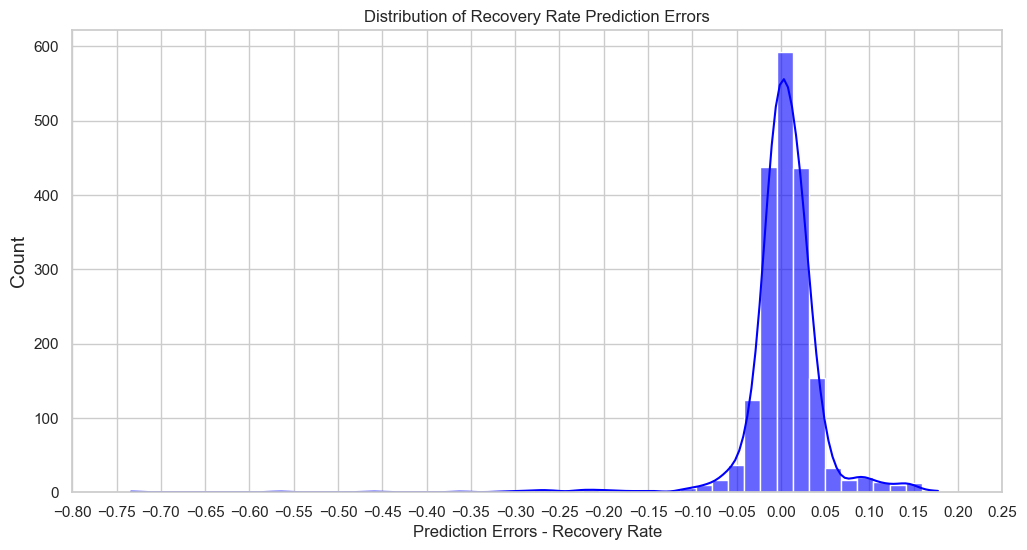

In [978]:
# Create the histogram with kernel density estimation
plt.figure(figsize=(12, 6))  # Set the figure size
sns.histplot(test_df_regression_results['prediction_errors'], 
             bins=50, 
             color='blue', 
             kde=True, 
             alpha=0.6)      # Set transparency for the histogram

# Set the x-ticks
plt.xticks(np.arange(-0.8, 0.3, 0.05))

# Set titles and labels
plt.title('Distribution of Recovery Rate Prediction Errors') 
plt.xlabel('Prediction Errors - Recovery Rate')                
plt.ylabel('Count', fontsize=14)                                


# Show the plot
plt.show()

- Insights: 
1. Most of the prediction errors are relatively low, which aligns with our Mean Absolute Residual (MAR) and Root Mean Squared Error (RMSE) metrics.

2. There are significant negative prediction errors, indicating that our model severely underestimates the user's recovery rate for some data points, or that the actual recovery amount from a loan greatly exceeds the model's expectations. Conversely, there are few large positive errors. While large prediction errors are not ideal, having more large negative errors is not necessarily detrimental from a risk management perspective. The underestimation of recovery rates may compel banks and financial lenders to reserve more capital for expected credit losses upon default. In practice, this may result in actual default amounts being lower than the model's predicted amounts.

---

### 4.3 Deep Dive on Large Error Predictions <a class="anchor" id="4c"></a>

In [984]:
# Extract predictions with large prediciton errors
large_pred_errors = test_df_regression_results[(test_df_regression_results['prediction_errors'] > 0.15) | (test_df_regression_results['prediction_errors'] < -0.15)]
large_pred_errors.head(20)

,funded_amnt,int_rate,grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,revol_util,total_acc,initial_list_status,mths_since_delinq_category,issue_year,issue_month,state_group,is_revl_acct,is_term_60_mths,derogatory_pub_rec,recovery_rate,predicted_recovery_rate,prediction_errors
326776,12500,22.1500,E,MORTGAGE,100000.0000,Source Verified,other,16.9900,0.0000,1.0000,94.2000,39.0000,w,Missing History,2014,6,State Group 6,1,0,0 record,0.0100,0.1874,0.1774
327314,3500,10.9900,B,RENT,33000.0000,Not Verified,debt_consolidation,8.6700,0.0000,1.0000,16.7000,21.0000,w,More than 2Yrs,2014,6,State Group 4,1,0,0 record,0.3500,0.1505,-0.1995
338496,3000,15.6100,D,RENT,60000.0000,Not Verified,moving,12.0400,1.0000,1.0000,64.4000,32.0000,w,in 1Yr,2014,7,State Group 3,1,0,0 record,0.3900,0.1645,-0.2255
344857,2800,20.2000,E,MORTGAGE,62000.0000,Not Verified,medical,34.3800,0.0000,1.0000,72.6000,37.0000,w,Missing History,2014,7,State Group 5,1,0,0 record,0.3600,0.1754,-0.1846
346583,10000,20.9900,E,MORTGAGE,85000.0000,Source Verified,other,10.3100,0.0000,2.0000,88.2000,16.0000,f,Missing History,2014,7,State Group 4,1,0,0 record,0.3500,0.1422,-0.2078
347854,15000,7.6900,A,MORTGAGE,87000.0000,Not Verified,debt_consolidation,10.0200,0.0000,1.0000,63.4000,27.0000,w,Missing History,2014,7,State Group 3,1,0,0 record,0.3900,0.1577,-0.2323
349201,7000,22.1500,E,RENT,22000.0000,Not Verified,credit_card,12.3300,0.0000,2.0000,26.8000,19.0000,f,More than 2Yrs,2014,7,State Group 3,1,0,0 record,0.4500,0.1349,-0.3151
352506,27200,20.9900,E,MORTGAGE,65000.0000,Verified,credit_card,30.1700,0.0000,0.0000,101.7000,26.0000,w,More than 2Yrs,2014,7,State Group 3,1,1,0 record,0.0100,0.1687,0.1587
353381,2000,22.1500,E,MORTGAGE,47904.0000,Not Verified,moving,26.1000,0.0000,1.0000,94.4000,26.0000,w,in 2Yrs,2014,7,State Group 4,1,0,0 record,0.4500,0.1788,-0.2712
353510,12000,12.4900,B,OWN,64000.0000,Verified,debt_consolidation,34.8700,0.0000,2.0000,47.5000,36.0000,w,Missing History,2014,7,State Group 5,1,0,0 record,0.0100,0.1662,0.1562


**Insights:**

There is a discernible pattern where the predicted recovery rate consistently falls within the range of 0.14 to 0.2. In contrast, the actual recovery rates exhibit significant deviations from this range, with values either approaching 0 or substantially exceeding the predicted recovery rates.

- Investigate Recovery Rate Distribution

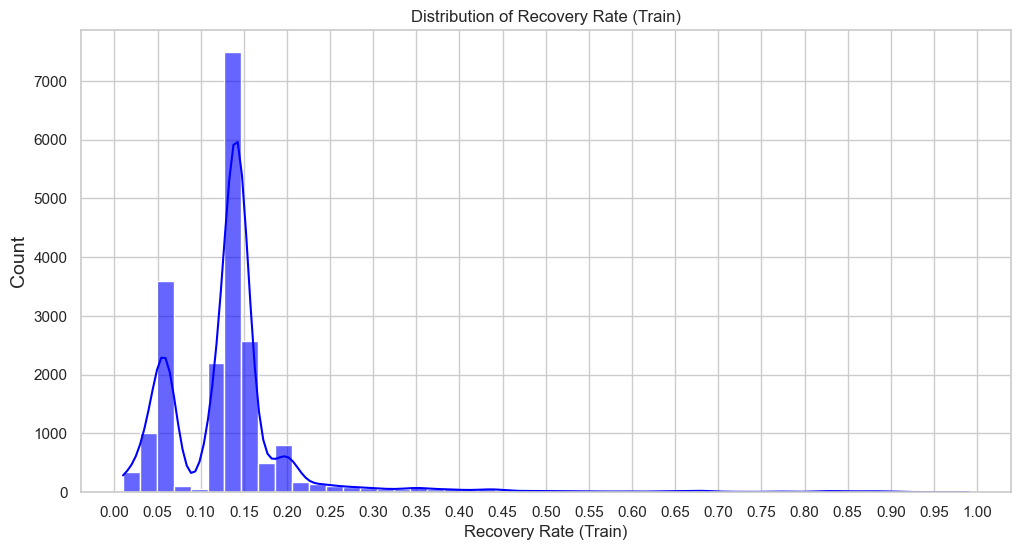

In [986]:
# Creat the distribution for recovery rate distribution
plt.figure(figsize=(12, 6))  
sns.histplot(y_train_regression, 
             bins=50, 
             color='blue', 
             kde=True, 
             alpha=0.6)    
            
plt.xticks(np.arange(0, 1.05, 0.05))

plt.title('Distribution of Recovery Rate (Train)') 
plt.xlabel('Recovery Rate (Train)')                
plt.ylabel('Count', fontsize=14)                                

# Show the plot
plt.show()

**Insights:** 

1. Despite filtering out peaks where the recovery rate equals 0 or 1, we still observe multimodal distributions in the recovery rates, with significant peaks around 0.05 and 0.15. Our model appears to be heavily influenced by the peak at 0.15, leading to many predictions clustered in this area, which results in extremely large errors when actual recovery rates are either near 0 (no recoveries) or greater than 0.5 (substantial recoveries).

2. We could further refine the model by developing additional classification models to filter out data points at the peaks around 0.15, thereby improving the precision of the estimated recovery rates. However, we must exercise caution against overengineering the problem, as increasing the number of models could amplify the impact of specific recovery rate outcomes.

3. The peak at 0.15 should be interpretable by individuals with domain knowledge related to recoveries from Lending Club; however, this insight is currently missing from our datasets. In real-world applications, it is beneficial to invest additional effort in consulting domain experts and seeking supplementary data to elucidate these patterns.

4. Consistent with our analysis of classification models, incorporating macroeconomic factors may also enhance the performance of the model in capturing economic influences on recovery rates.

---

## 5. Summary <a class="anchor" id="5"></a>

After finishing our steps 1 and steps 2, we can combine the predictions to calcualted the expected recovery rate:

$$E[\text{Recovery Rate}] = \text{P}(\text{RR} = 1) \cdot 1 + \text{P}(\text{RR} = 0) \cdot 0 + \text{P}(0 < \text{RR} < 1) \cdot E[\text{RR} | 0 < \text{RR} < 1]$$


After that, Loss Given Default can be calculated by: 

$$ E[\text{Loss Given Default}] = 1 - E[\text{Recovery Rate}]  $$

Here are the model performance summary for Step 1 and Step 2 models:

 Step 1: Classification Model (Logistic Regression) Metrics (Train)

| Metric                     | Value   |
|----------------------------|---------|
| AUC Score                  | 0.658   |
| Accuracy Score             | 0.618   |
| Recall Score               | 0.543   |
| False Positive Rate        | 0.312   |
| Precision Score            | 0.615   |
| F1 Score                  | 0.577   |

 Step 2: Beta Model Evaluation Metrics  

| Metric                    | Value   |
|---------------------------|---------|
| Mean Absolute Error (MAE) | 0.025   |
| Root Mean Squared Error (RMSE) | 0.047   |
| Mean Squared Error (MSE)  | 0.002   |

- **Takeaways:** 
  1. The shift in data distribution, particularly the significant changes in the proportions of recovery rates equal to 0 and 1 over time, has led to inconsistencies in model performance between the training and test sets. After addressing overfitting and verifying the distribution between these sets, we observe that while the model performs adequately on the training set, it remains unstable on the test set.
  
  2. The step 2 model performed relatively well in predicting the continuous recovery rate. However, it struggles with individuals who have high recovery rates (> 0.5). This is generally acceptable from a risk management perspective, as underestimating recovery rates will lead to an overestimation of loss given default and expected credit loss.
  
  3. Incorporating additional relevant features, such as variables that may explain the peak recovery rate at 0.15, or including macroeconomic variables, could enhance the model's ability to capture the economic factors influencing the distribution of recovery rates over time.